# Data Profiling Report
TikTok (sample 20 files / 51 GB) · X (full dataset ~43 MB)

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(150)
pl.Config.set_tbl_width_chars(300)

OUT = Path(r'c:\Users\MoZa\OneDrive - Universität Paderborn\0_UPB\BA\Repo\Bachelor-Arbeit\temp\profiling_output')
def load(f): return pl.read_csv(OUT / f)
PLATFORMS = ['tiktok', 'x']
COLORS    = {'tiktok': '#EE1D52', 'x': '#1DA1F2'}
print('Ready.')

Ready.


## 1  File Inventory

In [2]:
inv = pl.concat([load('tiktok_01_file_inventory.csv'), load('x_01_file_inventory.csv')])
print(inv)

shape: (2, 6)
┌──────────┬─────────────┬───────────────┬─────────────┬─────────────┬─────────────┐
│ platform ┆ total_files ┆ total_size_gb ┆ min_file_mb ┆ max_file_mb ┆ avg_file_mb │
│ ---      ┆ ---         ┆ ---           ┆ ---         ┆ ---         ┆ ---         │
│ str      ┆ i64         ┆ f64           ┆ f64         ┆ f64         ┆ f64         │
╞══════════╪═════════════╪═══════════════╪═════════════╪═════════════╪═════════════╡
│ tiktok   ┆ 1197        ┆ 51.45         ┆ 0.03        ┆ 103.38      ┆ 44.02       │
│ x        ┆ 291         ┆ 0.04          ┆ 0.02        ┆ 0.37        ┆ 0.15        │
└──────────┴─────────────┴───────────────┴─────────────┴─────────────┴─────────────┘


## 2  Schema

In [3]:
tt_schema = load('tiktok_02_schema.csv')
x_schema  = load('x_02_schema.csv')
merged = tt_schema.rename({'dtype': 'dtype_tiktok'}).join(
    x_schema.rename({'dtype': 'dtype_x'}).drop('platform'),
    on='column', how='full', coalesce=True
)
print(f'TikTok columns: {len(tt_schema)}  |  X columns: {len(x_schema)}')
print(merged)

TikTok columns: 37  |  X columns: 37
shape: (37, 4)
┌──────────┬──────────────────────────────────┬──────────────────────────────────────────┬──────────────────────────────────────────┐
│ platform ┆ column                           ┆ dtype_tiktok                             ┆ dtype_x                                  │
│ ---      ┆ ---                              ┆ ---                                      ┆ ---                                      │
│ str      ┆ str                              ┆ str                                      ┆ str                                      │
╞══════════╪══════════════════════════════════╪══════════════════════════════════════════╪══════════════════════════════════════════╡
│ tiktok   ┆ uuid                             ┆ String                                   ┆ String                                   │
│ tiktok   ┆ decision_visibility              ┆ String                                   ┆ String                                   │
│ tiktok  

## 3  Missing Data (Null + Empty Strings)

In [4]:
tt_null = load('tiktok_04_null_empty.csv').select(['column','null_pct','empty_str_pct','total_missing_pct'])
x_null  = load('x_04_null_empty.csv').select(['column','null_pct','empty_str_pct','total_missing_pct'])
print('--- TikTok: columns with >0% missing ---')
print(tt_null.filter(pl.col('total_missing_pct') > 0).sort('total_missing_pct', descending=True))
print('\n--- X: columns with >0% missing ---')
print(x_null.filter(pl.col('total_missing_pct') > 0).sort('total_missing_pct', descending=True))

--- TikTok: columns with >0% missing ---
shape: (23, 4)
┌──────────────────────────────────┬──────────┬───────────────┬───────────────────┐
│ column                           ┆ null_pct ┆ empty_str_pct ┆ total_missing_pct │
│ ---                              ┆ ---      ┆ ---           ┆ ---               │
│ str                              ┆ f64      ┆ f64           ┆ f64               │
╞══════════════════════════════════╪══════════╪═══════════════╪═══════════════════╡
│ decision_monetary                ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ decision_monetary_other          ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ end_date_monetary_restriction    ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ end_date_account_restriction     ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ account_type                     ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ decision_ground_reference_url    ┆ 100.0    ┆ 0.0           ┆ 100.0             │
│ incompatible_conte

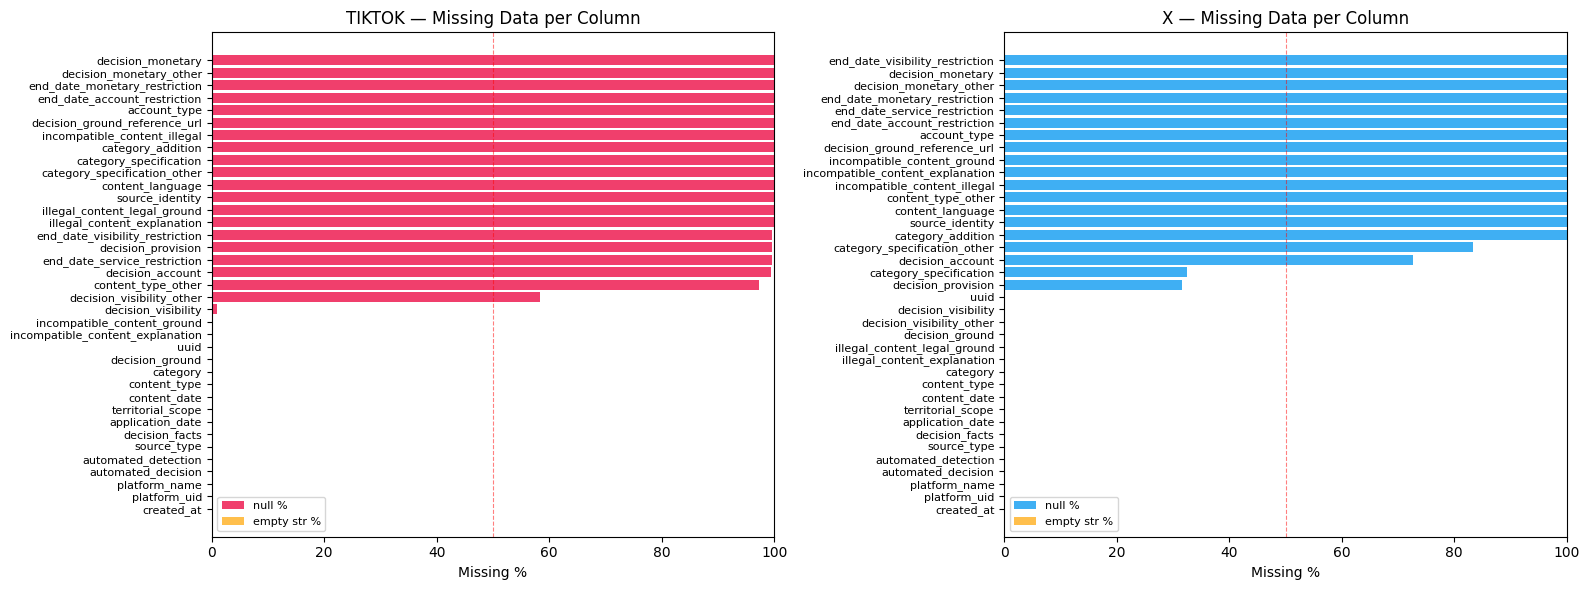

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, df) in zip(axes, [('tiktok', tt_null), ('x', x_null)]):
    df_sorted = df.sort('total_missing_pct', descending=True)
    cols  = df_sorted['column'].to_list()
    nulls = df_sorted['null_pct'].to_list()
    empty = df_sorted['empty_str_pct'].to_list()
    y = np.arange(len(cols))
    ax.barh(y, nulls, color=COLORS[name], alpha=0.85, label='null %')
    ax.barh(y, empty, left=nulls, color='orange', alpha=0.7, label='empty str %')
    ax.set_yticks(y); ax.set_yticklabels(cols, fontsize=8)
    ax.set_xlabel('Missing %')
    ax.set_title(f'{name.upper()} — Missing Data per Column')
    ax.axvline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / 'plot_missing_data.png', dpi=130, bbox_inches='tight')
plt.show()

## 4  Cardinality (Unique Values per Column)

In [6]:
tt_card = load('tiktok_05_cardinality.csv')
x_card  = load('x_05_cardinality.csv')
merged_card = tt_card.rename({'n_unique': 'n_unique_tiktok'}).drop(['platform','source']).join(
    x_card.rename({'n_unique': 'n_unique_x'}).drop(['platform','source']),
    on='column', how='full', coalesce=True
).sort('n_unique_tiktok', descending=True, nulls_last=True)
print(merged_card)

shape: (37, 3)
┌──────────────────────────────────┬─────────────────┬────────────┐
│ column                           ┆ n_unique_tiktok ┆ n_unique_x │
│ ---                              ┆ ---             ┆ ---        │
│ str                              ┆ i64             ┆ i64        │
╞══════════════════════════════════╪═════════════════╪════════════╡
│ uuid                             ┆ 15439990        ┆ 670093     │
│ platform_uid                     ┆ 15437058        ┆ 670093     │
│ created_at                       ┆ 165123          ┆ 399153     │
│ incompatible_content_explanation ┆ 6127            ┆ 1          │
│ territorial_scope                ┆ 4789            ┆ 27         │
│ content_date                     ┆ 3762            ┆ 366        │
│ incompatible_content_ground      ┆ 2543            ┆ 1          │
│ end_date_service_restriction     ┆ 146             ┆ 1          │
│ end_date_visibility_restriction  ┆ 87              ┆ 1          │
│ decision_visibility_other      

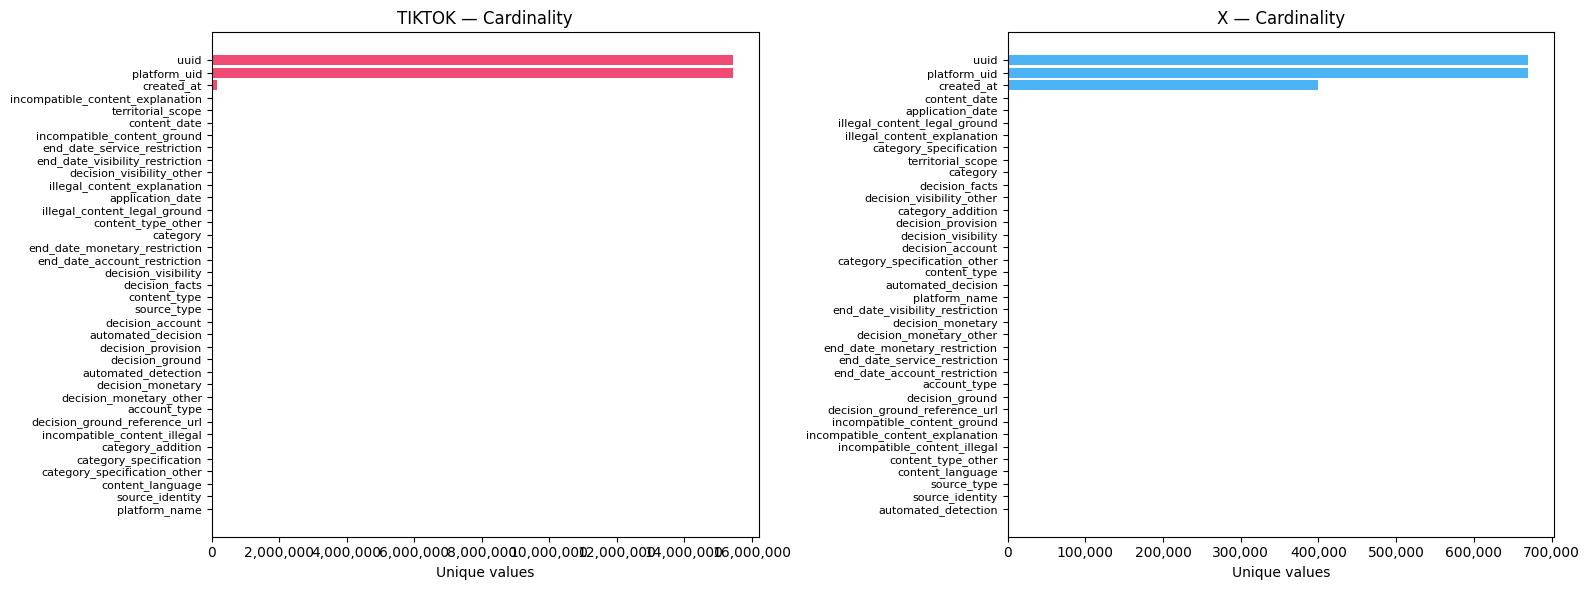

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, df) in zip(axes, [('tiktok', tt_card), ('x', x_card)]):
    df_s = df.sort('n_unique', descending=True)
    cols = df_s['column'].to_list()
    vals = df_s['n_unique'].to_list()
    y = np.arange(len(cols))
    ax.barh(y, vals, color=COLORS[name], alpha=0.8)
    ax.set_yticks(y); ax.set_yticklabels(cols, fontsize=8)
    ax.set_xlabel('Unique values')
    ax.set_title(f'{name.upper()} — Cardinality')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / 'plot_cardinality.png', dpi=130, bbox_inches='tight')
plt.show()

## 5  Top-10 Values per Column

In [8]:
tt_topn = load('tiktok_06_topn_values.csv')
x_topn  = load('x_06_topn_values.csv')
for name, df in [('TIKTOK', tt_topn), ('X', x_topn)]:
    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    for col in df['column'].unique(maintain_order=True).to_list():
        subset = df.filter(pl.col('column') == col).sort('rank')
        print(f'\n  [{col}]')
        print(subset.select(['rank','value','count','pct']))


  TIKTOK

  [uuid]
shape: (10, 4)
┌──────┬──────────────────────────────────────┬───────┬──────┐
│ rank ┆ value                                ┆ count ┆ pct  │
│ ---  ┆ ---                                  ┆ ---   ┆ ---  │
│ i64  ┆ str                                  ┆ i64   ┆ f64  │
╞══════╪══════════════════════════════════════╪═══════╪══════╡
│ 1    ┆ 6da67ef0-cf59-4c62-acbd-3d2781631e8c ┆ 1     ┆ 10.0 │
│ 2    ┆ 60ac38ea-5e78-41cd-b84a-0dab1cca5fe1 ┆ 1     ┆ 10.0 │
│ 3    ┆ 2185ffa5-21a6-4902-80f6-8b98ba5f9407 ┆ 1     ┆ 10.0 │
│ 4    ┆ 9001cc51-0268-4d34-8510-0fd018243b4e ┆ 1     ┆ 10.0 │
│ 5    ┆ f0a2d62b-906a-4230-9dc2-f08df57a22b9 ┆ 1     ┆ 10.0 │
│ 6    ┆ 77a77486-a84b-4c9d-9222-ae23ad321bb1 ┆ 1     ┆ 10.0 │
│ 7    ┆ b6adbe68-ffb4-44c7-9881-d56b9e47d2c4 ┆ 1     ┆ 10.0 │
│ 8    ┆ 4292dc63-a825-43ec-81fd-dab500ba3158 ┆ 1     ┆ 10.0 │
│ 9    ┆ 8b6a694a-794f-4b49-ad4d-019a20ed2d48 ┆ 1     ┆ 10.0 │
│ 10   ┆ 93eaf939-1f0a-469e-9141-4f3e05668ef9 ┆ 1     ┆ 10.0 │
└──────┴────────────

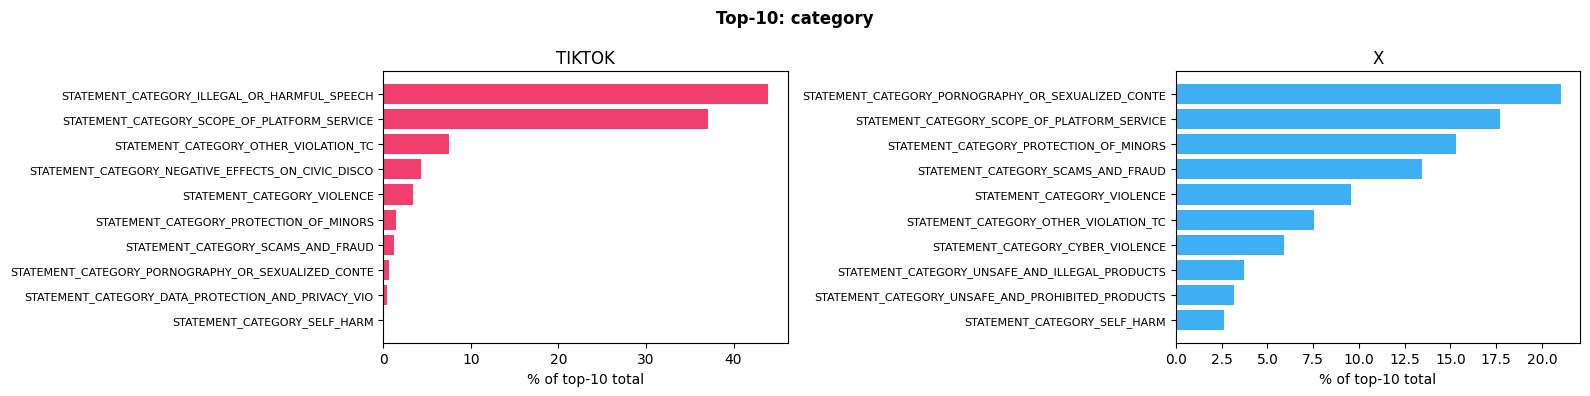

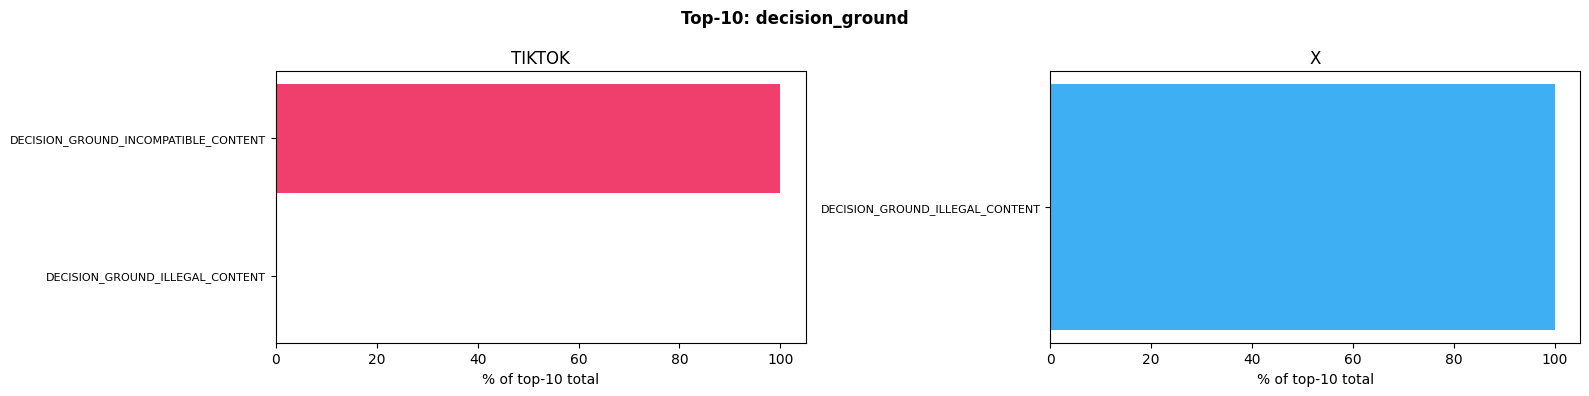

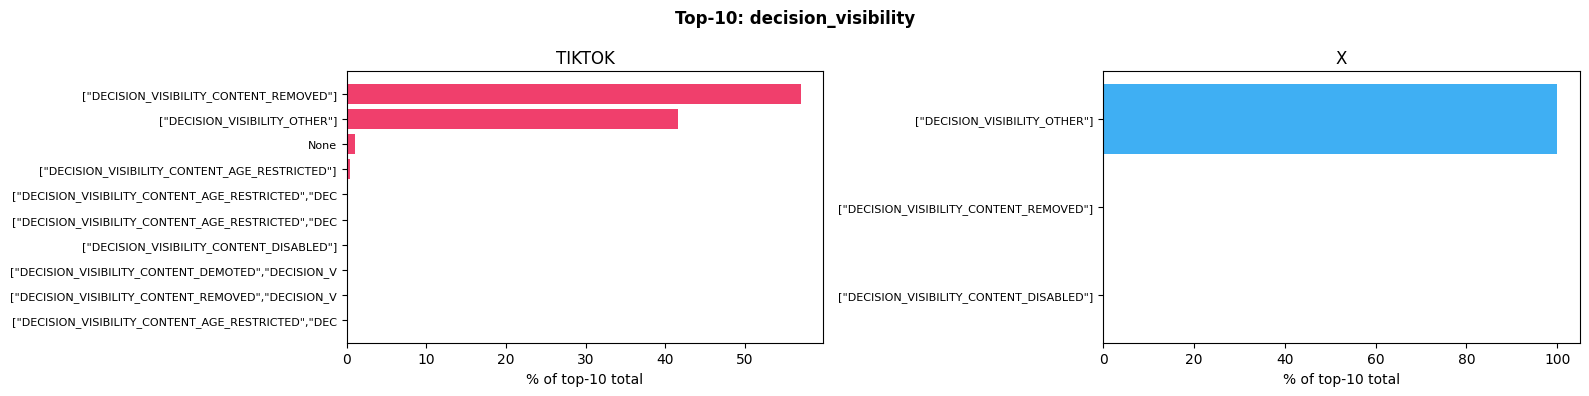

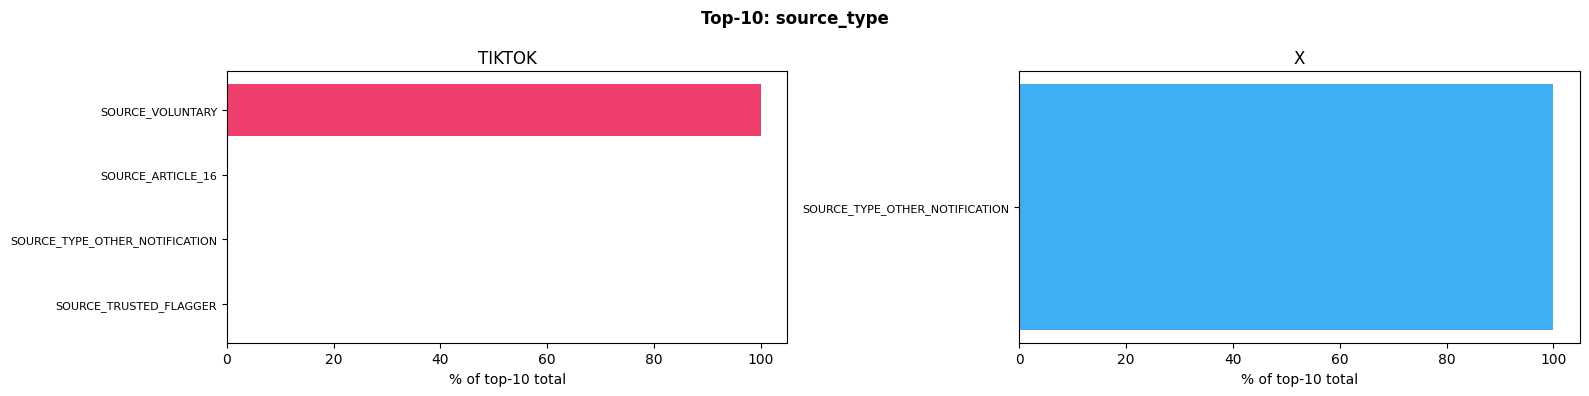

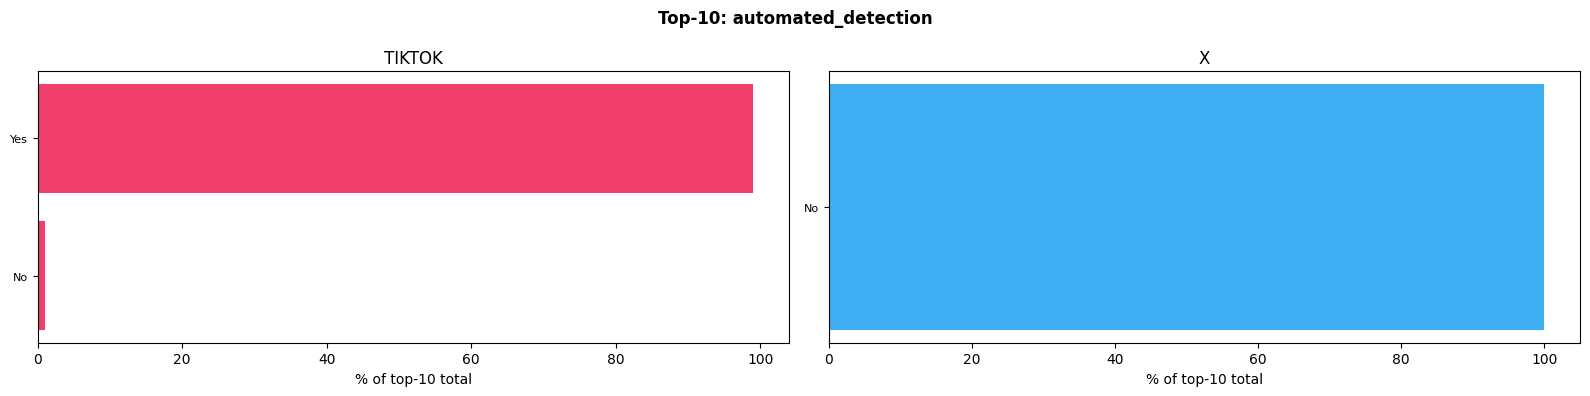

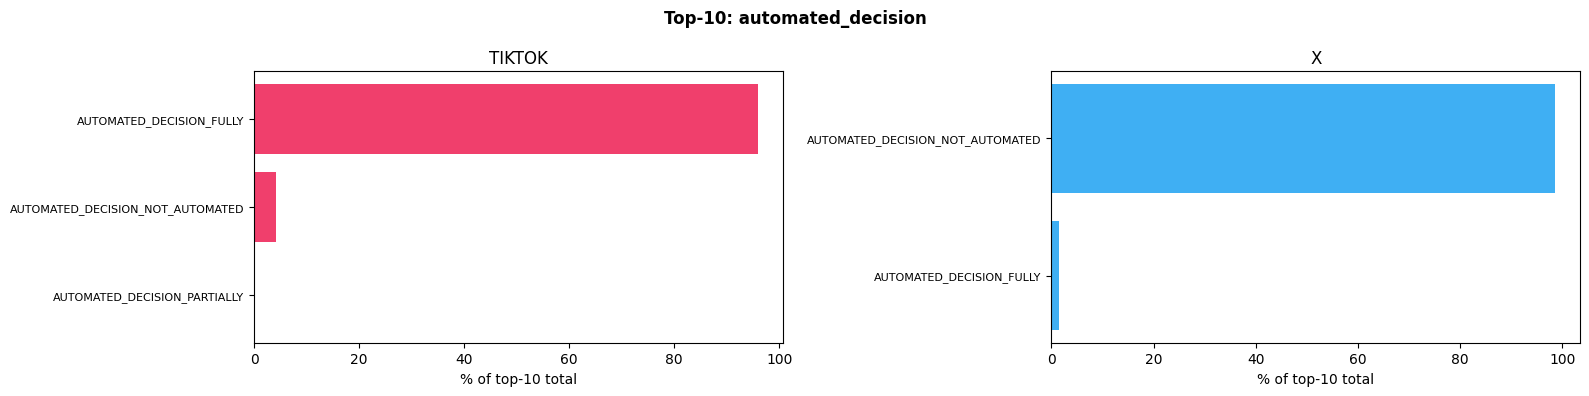

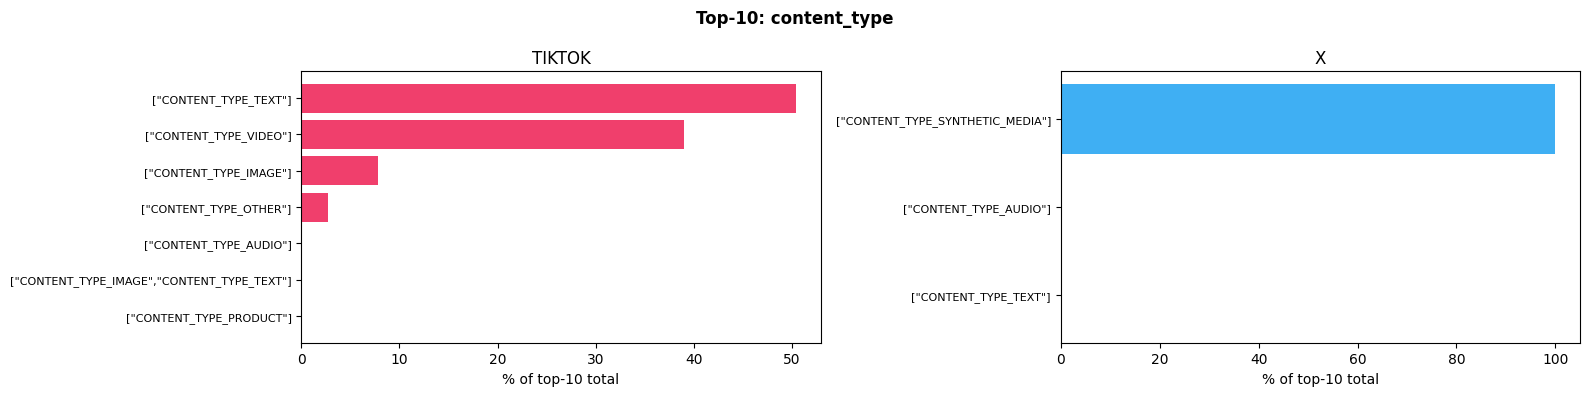

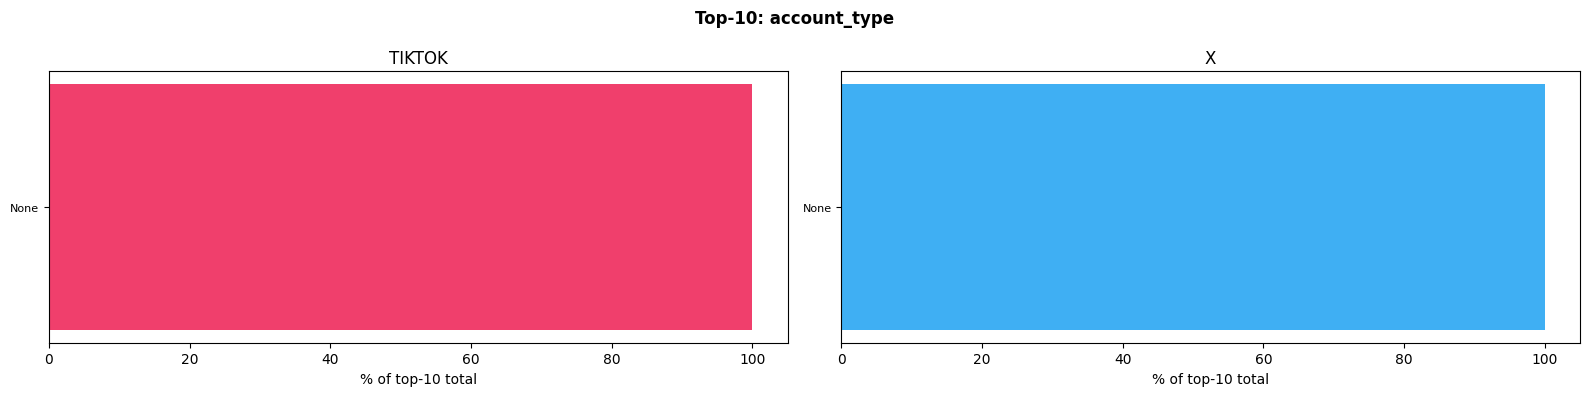

In [9]:
FOCUS_COLS = ['category','decision_ground','decision_visibility',
              'source_type','automated_detection','automated_decision',
              'content_type','account_type']
for col in FOCUS_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle(f'Top-10: {col}', fontsize=12, fontweight='bold')
    for ax, (name, df) in zip(axes, [('tiktok', tt_topn), ('x', x_topn)]):
        subset = df.filter(pl.col('column') == col).sort('rank')
        if len(subset) == 0: ax.set_visible(False); continue
        labels = [str(v)[:50] for v in subset['value'].to_list()]
        pcts   = subset['pct'].to_list()
        y = np.arange(len(labels))
        ax.barh(y, pcts, color=COLORS[name], alpha=0.85)
        ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('% of top-10 total'); ax.set_title(f'{name.upper()}')
        ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(OUT / f'plot_topn_{col}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6  String Length Stats

In [10]:
tt_str = load('tiktok_07_string_stats.csv')
x_str  = load('x_07_string_stats.csv')
merged_str = tt_str.drop(['platform','source']).rename(
    {'len_min':'tt_len_min','len_max':'tt_len_max','len_mean':'tt_len_mean','whitespace_anomaly_count':'tt_ws'}
).join(
    x_str.drop(['platform','source']).rename(
        {'len_min':'x_len_min','len_max':'x_len_max','len_mean':'x_len_mean','whitespace_anomaly_count':'x_ws'}
    ), on='column', how='full', coalesce=True
)
print(merged_str)
print('\n--- Whitespace anomalies ---')
print('TikTok:', tt_str.filter(pl.col('whitespace_anomaly_count') > 0))
print('X:',      x_str.filter(pl.col('whitespace_anomaly_count') > 0))

shape: (30, 9)
┌──────────────────────────────────┬────────────┬────────────┬─────────────┬───────┬───────────┬───────────┬────────────┬──────┐
│ column                           ┆ tt_len_min ┆ tt_len_max ┆ tt_len_mean ┆ tt_ws ┆ x_len_min ┆ x_len_max ┆ x_len_mean ┆ x_ws │
│ ---                              ┆ ---        ┆ ---        ┆ ---         ┆ ---   ┆ ---       ┆ ---       ┆ ---        ┆ ---  │
│ str                              ┆ i64        ┆ i64        ┆ f64         ┆ i64   ┆ i64       ┆ i64       ┆ f64        ┆ i64  │
╞══════════════════════════════════╪════════════╪════════════╪═════════════╪═══════╪═══════════╪═══════════╪════════════╪══════╡
│ uuid                             ┆ 36         ┆ 36         ┆ 36.0        ┆ 0     ┆ 36        ┆ 36        ┆ 36.0       ┆ 0    │
│ decision_visibility              ┆ 29         ┆ 112        ┆ 34.84       ┆ 0     ┆ 29        ┆ 40        ┆ 29.0       ┆ 0    │
│ decision_visibility_other        ┆ 3          ┆ 193        ┆ 59.5        ┆ 0    

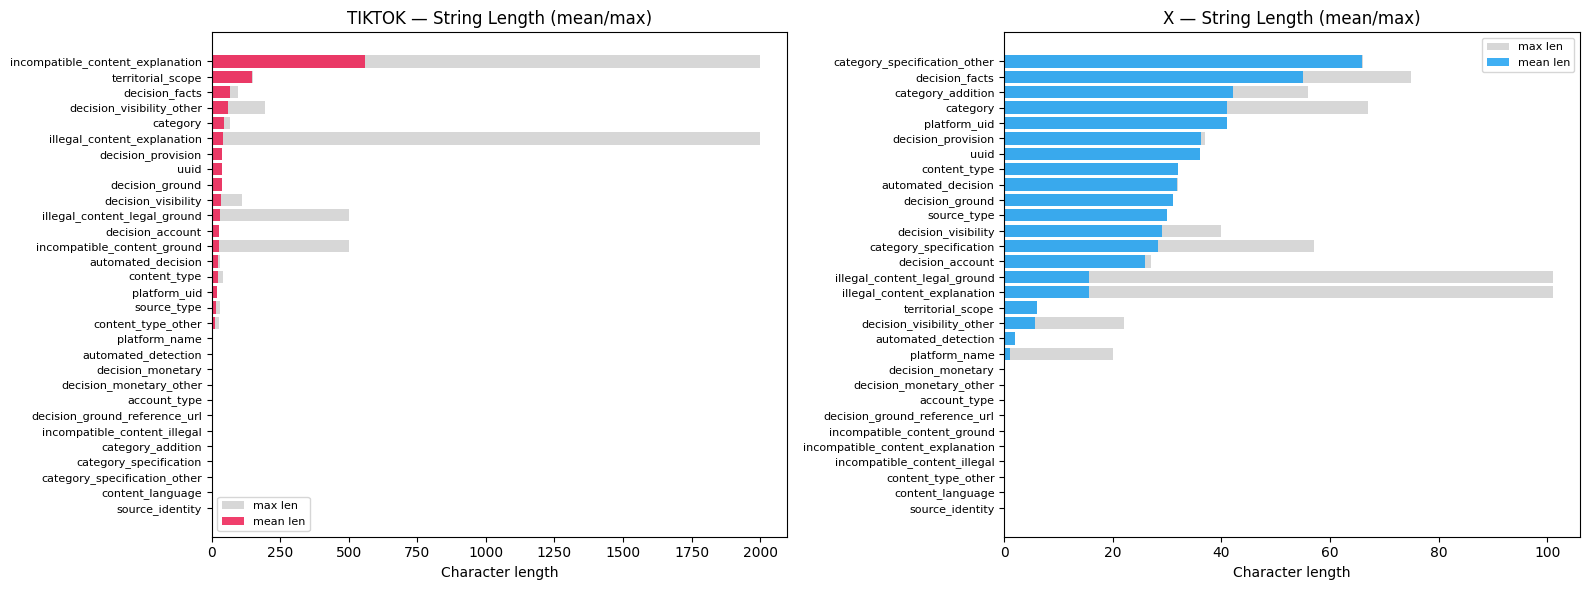

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, df) in zip(axes, [('tiktok', tt_str), ('x', x_str)]):
    df_s = df.sort('len_mean', descending=True)
    cols  = df_s['column'].to_list()
    lmin  = df_s['len_min'].to_list()
    lmax  = df_s['len_max'].to_list()
    lmean = df_s['len_mean'].to_list()
    y = np.arange(len(cols))
    ax.barh(y, lmax,  color='lightgrey', alpha=0.9, label='max len')
    ax.barh(y, lmean, color=COLORS[name], alpha=0.85, label='mean len')
    ax.set_yticks(y); ax.set_yticklabels(cols, fontsize=8)
    ax.set_xlabel('Character length')
    ax.set_title(f'{name.upper()} — String Length (mean/max)')
    ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / 'plot_string_lengths.png', dpi=130, bbox_inches='tight')
plt.show()

## 7  Quality Summary

In [12]:
tt_null_full = load('tiktok_04_null_empty.csv')
x_null_full  = load('x_04_null_empty.csv')
for name, null_df, card_df, str_df in [
    ('TIKTOK', tt_null_full, tt_card, tt_str),
    ('X',      x_null_full,  x_card,  x_str),
]:
    print(f'\n=== {name} ===')
    print(f'  Columns >50% missing:  {null_df.filter(pl.col("total_missing_pct") > 50)["column"].to_list()}')
    print(f'  Columns >10% missing:  {null_df.filter(pl.col("total_missing_pct") > 10)["column"].to_list()}')
    print(f'  Constant cols (1 uniq): {card_df.filter(pl.col("n_unique") == 1)["column"].to_list()}')
    print(f'  Whitespace anomalies:   {str_df.filter(pl.col("whitespace_anomaly_count") > 0)[["column","whitespace_anomaly_count"]].rows()}')


=== TIKTOK ===
  Columns >50% missing:  ['decision_visibility_other', 'end_date_visibility_restriction', 'decision_monetary', 'decision_monetary_other', 'end_date_monetary_restriction', 'decision_provision', 'end_date_service_restriction', 'decision_account', 'end_date_account_restriction', 'account_type', 'decision_ground_reference_url', 'illegal_content_legal_ground', 'illegal_content_explanation', 'incompatible_content_illegal', 'category_addition', 'category_specification', 'category_specification_other', 'content_type_other', 'content_language', 'source_identity']
  Columns >10% missing:  ['decision_visibility_other', 'end_date_visibility_restriction', 'decision_monetary', 'decision_monetary_other', 'end_date_monetary_restriction', 'decision_provision', 'end_date_service_restriction', 'decision_account', 'end_date_account_restriction', 'account_type', 'decision_ground_reference_url', 'illegal_content_legal_ground', 'illegal_content_explanation', 'incompatible_content_illegal', 'c